In [1]:
import json
import os
from glob import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
from Configs import BASE_PATH

MODEL_PATH = BASE_PATH / 'Models'

print(BASE_PATH)
print(MODEL_PATH)

C:\Users\minem\PycharmProjects\ITS-M\Master\GroovePal
C:\Users\minem\PycharmProjects\ITS-M\Master\GroovePal\Models


# Comparing Model Stats

In [3]:
# Paths

all_paths = set(MODEL_PATH.glob('*/checkpoints/training_stats.jsonl'))
intermediate_paths = set(MODEL_PATH.glob('intermediate*/checkpoints/training_stats.jsonl'))
finetuned_paths = set(MODEL_PATH.glob('finetuned*/checkpoints/training_stats.jsonl'))

pretrained_paths = all_paths - intermediate_paths - finetuned_paths

only_class_path = next((p for p in pretrained_paths if 'mt_relgu' in str(p)), None)
mixed_loss_path = next((p for p in pretrained_paths if 'mixedLoss' in str(p)), None)
naive_loss_path = next((p for p in pretrained_paths if 'naive' in str(p)), None)
manual_loss_path = next((p for p in pretrained_paths if 'manual' in str(p)), None)
uncertainty_loss_path = next((p for p in pretrained_paths if 'uncertainty' in str(p)), None)

In [4]:
special_paths = {
    "only_class": only_class_path,
    "mixed_loss": mixed_loss_path,
    "naive_loss": naive_loss_path,
    "manual_loss": manual_loss_path,
    "uncertainty_loss": uncertainty_loss_path,
}

# remove found ones from pretrained_paths
for p in list(special_paths.values()):
    if p and p in pretrained_paths:
        pretrained_paths.remove(p)

In [5]:
# --- build category mapping ---
path_categories = {}
for p in pretrained_paths:
    path_categories[p] = "pretrained"
for p in intermediate_paths:
    path_categories[p] = "intermediate"
for p in finetuned_paths:
    path_categories[p] = "finetuned"
for name, p in special_paths.items():
    if p:
        path_categories[p] = f"special_{name}"

In [6]:
# --- read JSONL and build DataFrame ---
records = []

for path, category in path_categories.items():
    model_name = path.parts[-3]  # ../model_name/checkpoints/training_stats.jsonl
    with open(path, "r") as f:
        for line in f:
            entry = json.loads(line)
            entry["model"] = model_name
            entry["category"] = category
            records.append(entry)

df = pd.DataFrame(records)

In [7]:
# Flatten metrics + loss_log_vars
metrics_df = pd.json_normalize(df.pop("metrics"))
lossvars_df = pd.json_normalize(df.pop("loss_log_vars"))

df = pd.concat([df, metrics_df, lossvars_df.add_prefix("loss_log_vars.")], axis=1)

# Timestamps to datetime
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])

# Sort for clarity
df = df.sort_values(["category", "model", "epoch"]).reset_index(drop=True)

In [8]:
df

,epoch,global_step,start_time,end_time,elapsed_sec,train_loss,val_loss,monitor,mode,vram_peak_mb,...,offset/accuracy,offset/top_k_accuracy@3,offset/perplexity,loss_log_vars.beat_unit,loss_log_vars.bpm,loss_log_vars.grid_factor,loss_log_vars.instrument,loss_log_vars.offset,loss_log_vars.time_signature,loss_log_vars.velocity
0,0,521,2025-09-16 11:37:53,2025-09-16 11:38:30,37.06,5.030419,4.724968,val_loss,min,4591.06,...,NaN,NaN,NaN,0.157817,0.142191,0.119747,0.129078,0.119177,0.119297,0.119185
1,1,1042,2025-09-16 11:38:32,2025-09-16 11:39:08,36.07,4.709550,4.517818,val_loss,min,4575.83,...,NaN,NaN,NaN,0.175631,0.127541,0.094453,0.111631,0.093359,0.093753,0.093368
2,2,1563,2025-09-16 11:39:10,2025-09-16 11:39:47,37.09,4.543107,4.399539,val_loss,min,4585.05,...,NaN,NaN,NaN,0.189830,0.104762,0.069877,0.097599,0.068043,0.068887,0.068063
3,3,2084,2025-09-16 11:39:49,2025-09-16 11:41:16,87.14,4.427814,4.294652,val_loss,min,21879.20,...,NaN,NaN,NaN,0.199780,0.081027,0.046235,0.085296,0.043583,0.045022,0.043614
4,4,2605,2025-09-16 11:41:18,2025-09-16 11:42:47,89.70,4.326925,4.211638,val_loss,min,21885.14,...,NaN,NaN,NaN,0.206269,0.057928,0.023715,0.074088,0.020230,0.022463,0.020275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,25,13546,2025-09-29 14:06:16,2025-09-29 14:07:51,95.90,-1.313335,-1.060573,val_loss,min,22537.86,...,NaN,NaN,NaN,0.549676,0.329078,-0.171086,0.556216,-6.159770,0.095327,-6.457849
500,26,14067,2025-09-29 14:07:54,2025-09-29 14:09:31,96.68,-1.334876,-1.064851,val_loss,min,22539.96,...,NaN,NaN,NaN,0.549482,0.328454,-0.171091,0.555652,-6.165686,0.095683,-6.465581
501,27,14588,2025-09-29 14:09:34,2025-09-29 14:11:12,97.71,-1.334960,-1.066915,val_loss,min,22543.47,...,NaN,NaN,NaN,0.549184,0.328290,-0.171111,0.555024,-6.168675,0.095263,-6.469573
502,28,15109,2025-09-29 14:11:15,2025-09-29 14:12:51,96.38,-1.335096,-1.068734,val_loss,min,22541.65,...,NaN,NaN,NaN,0.549071,0.328320,-0.171071,0.554790,-6.169861,0.095407,-6.471136


In [9]:
df_best = (
    df.dropna(subset=["val_loss"])
      .sort_values(["model", "val_loss"], ascending=[True, True])
      .groupby("model", as_index=False)
      .first()  # lowest val_loss per model
)

df_best = df_best.sort_values("val_loss").reset_index(drop=True)
df_best

,model,epoch,global_step,start_time,end_time,elapsed_sec,train_loss,val_loss,monitor,mode,...,offset/accuracy,offset/top_k_accuracy@3,offset/perplexity,loss_log_vars.beat_unit,loss_log_vars.bpm,loss_log_vars.grid_factor,loss_log_vars.instrument,loss_log_vars.offset,loss_log_vars.time_signature,loss_log_vars.velocity
0,multitask_relativeGridUnits,29,173250,2025-08-29 07:36:56,2025-08-29 08:13:25,2189.23,-2.970067,-3.066018,val_loss,min,...,NaN,NaN,NaN,-0.197397,-0.379174,-0.865231,-0.309464,-7.224671,-0.600483,-7.939294
1,multitask_absoluteGridUnits,29,173250,2025-08-29 11:36:46,2025-08-29 12:11:55,2109.17,-2.573233,-2.658201,val_loss,min,...,NaN,NaN,NaN,0.152687,-0.372182,-0.865231,-0.299846,-7.197906,-0.598537,-7.900545
2,multitask_relativeGridUnits_uncertainty_loss,29,15630,2025-09-29 14:12:55,2025-09-29 14:14:33,98.69,-1.349516,-1.069032,val_loss,min,...,NaN,NaN,NaN,0.549026,0.328303,-0.171087,0.554740,-6.170132,0.095394,-6.471509
3,multitask_relGridUnits_mixedLoss,19,115500,2025-08-22 02:32:14,2025-08-22 03:08:19,2165.81,0.390518,0.368824,val_loss,min,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,multitask_relativeGridUnits_manual_loss,29,15630,2025-09-29 14:12:46,2025-09-29 14:14:23,97.45,0.389175,0.396813,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,mt_relgu_nopos,8,2637,2025-08-11 14:21:57,2025-08-11 14:47:40,1542.74,0.785825,0.780781,val_loss,min,...,0.06564,0.215591,5.540998,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,sequential_relativeGridUnits_bpe,29,173250,2025-08-30 16:32:31,2025-08-30 17:34:29,3717.43,1.576323,1.536604,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,sequential_absoluteGridUnits,29,173250,2025-09-01 18:04:53,2025-09-01 19:06:48,3715.66,1.587595,1.545471,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,sequential_relativeGridUnits,29,173250,2025-08-30 16:43:31,2025-08-30 17:44:58,3686.73,1.587595,1.545471,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,sequential_absoluteGridUnits_bpe,29,173250,2025-09-01 18:09:12,2025-09-01 19:10:41,3688.64,1.585844,1.545677,val_loss,min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
from GrooveModel.Vocab import INSTRUMENT_VOCAB_SIZE, VELOCITY_VOCAB_SIZE, OFFSET_VOCAB_SIZE, BPM_VOCAB_SIZE, \
    TIME_SIGNATURE_VOCAB_SIZE, GRID_FACTOR_VOCAB_SIZE, BEAT_UNIT_ABSOLUTE_VOCAB_SIZE, BEAT_UNIT_RELATIVE_VOCAB_SIZE

# Random baselines
random_lines = {
    "instrument/accuracy": 1 / INSTRUMENT_VOCAB_SIZE,
    "velocity/accuracy": 1 / VELOCITY_VOCAB_SIZE,
    "offset/accuracy": 1 / OFFSET_VOCAB_SIZE,
    "bpm/accuracy": 1 / BPM_VOCAB_SIZE,
    "time_signature/accuracy": 1 / TIME_SIGNATURE_VOCAB_SIZE,
    "grid_factor/accuracy": 1 / GRID_FACTOR_VOCAB_SIZE,
}

# Add beat_unit depending on model type (abs/rel)
for model in df_best["model"].unique():
    if "abs" in model.lower():
        random_lines[f"{model}_beat_unit"] = 1 / BEAT_UNIT_ABSOLUTE_VOCAB_SIZE
    elif "rel" in model.lower():
        random_lines[f"{model}_beat_unit"] = 1 / BEAT_UNIT_RELATIVE_VOCAB_SIZE

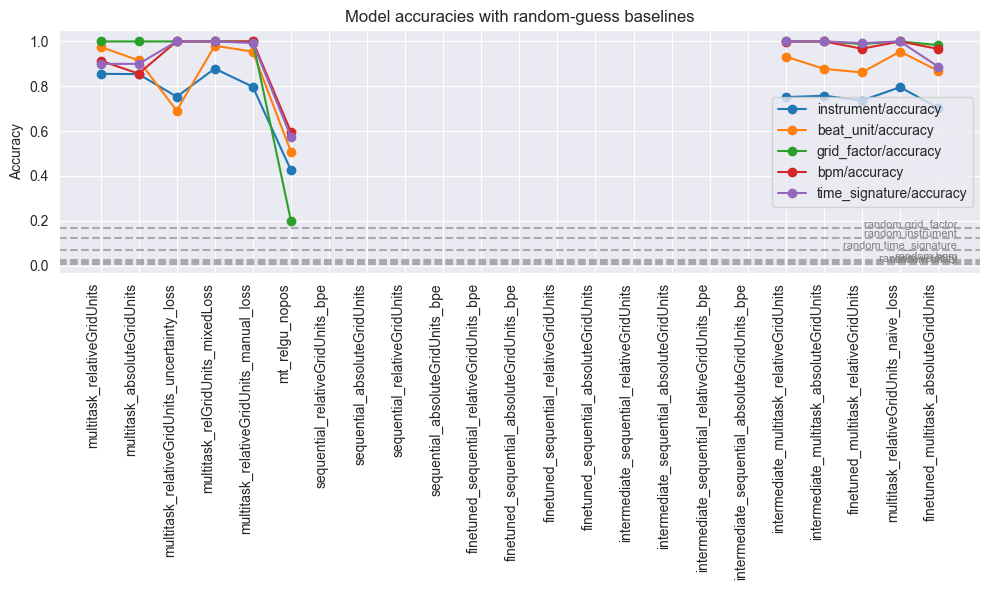

In [12]:
accuracy_cols = [
    "instrument/accuracy",
    "beat_unit/accuracy",
    "grid_factor/accuracy",
    "bpm/accuracy",
    "time_signature/accuracy",
]

plt.figure(figsize=(10, 6))
for col in accuracy_cols:
    if col in df_best.columns:
        plt.plot(df_best["model"], df_best[col], 'o-', label=col)

# Add random baseline lines
for label, baseline in random_lines.items():
    # only draw the generic ones (instrument, bpm, etc.)
    if "/" in label:
        plt.axhline(y=baseline, color='gray', linestyle='--', alpha=0.6)
        plt.text(len(df_best) - 0.5, baseline + 0.002, f"random {label.split('/')[0]}",
                 color='gray', fontsize=8, ha='right')

plt.xticks(rotation=90, ha='right')
plt.ylabel("Accuracy")
plt.title("Model accuracies with random-guess baselines")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
base_cols = ['model', 'epoch', 'val_loss', 'elapsed_sec', 'category']

cols = list(df_best.columns)

# Create a filtered list instead of removing while iterating
cols = [
    col for col in cols
    if (
        col in base_cols or
        (any(metric in col for metric in ['accuracy', 'perplexity', 'mae', 'mse']) and '@' not in col)
    )
]

cols

['model',
 'epoch',
 'elapsed_sec',
 'val_loss',
 'category',
 'instrument/accuracy',
 'instrument/perplexity',
 'beat_unit/accuracy',
 'beat_unit/perplexity',
 'grid_factor/accuracy',
 'grid_factor/perplexity',
 'bpm/accuracy',
 'bpm/perplexity',
 'time_signature/accuracy',
 'time_signature/perplexity',
 'velocity/mse',
 'velocity/mae',
 'offset/mse',
 'offset/mae',
 'accuracy',
 'perplexity',
 'velocity/accuracy',
 'velocity/perplexity',
 'offset/accuracy',
 'offset/perplexity']

In [27]:
model_stats = df_best[cols]
model_stats

,model,epoch,elapsed_sec,val_loss,category,instrument/accuracy,instrument/perplexity,beat_unit/accuracy,beat_unit/perplexity,grid_factor/accuracy,...,velocity/mse,velocity/mae,offset/mse,offset/mae,accuracy,perplexity,velocity/accuracy,velocity/perplexity,offset/accuracy,offset/perplexity
0,multitask_relativeGridUnits,29,2189.23,-3.066018,pretrained,0.855470,1.490375,0.975556,1.193748,1.000000,...,0.026200,0.069246,0.066012,0.098468,NaN,NaN,NaN,NaN,NaN,NaN
1,multitask_absoluteGridUnits,29,2109.17,-2.658201,pretrained,0.854342,1.499572,0.915711,1.210473,1.000000,...,0.026882,0.070837,0.067587,0.100324,NaN,NaN,NaN,NaN,NaN,NaN
2,multitask_relativeGridUnits_uncertainty_loss,29,98.69,-1.069032,special_uncertainty_loss,0.753495,1.799452,0.691407,1.232989,1.000000,...,0.045100,0.095807,0.080920,0.119130,NaN,NaN,NaN,NaN,NaN,NaN
3,multitask_relGridUnits_mixedLoss,19,2165.81,0.368824,special_mixed_loss,0.878868,1.292323,0.981053,1.064513,1.000000,...,0.025909,0.077149,0.065961,0.107860,NaN,NaN,NaN,NaN,NaN,NaN
4,multitask_relativeGridUnits_manual_loss,29,97.45,0.396813,special_manual_loss,0.797735,1.698573,0.954437,1.215962,1.000000,...,0.043508,0.098376,0.078831,0.123943,NaN,NaN,NaN,NaN,NaN,NaN
5,mt_relgu_nopos,8,1542.74,0.780781,special_only_class,0.426258,1.867141,0.508976,1.185469,0.200788,...,NaN,NaN,NaN,NaN,NaN,NaN,0.041677,15.8355,0.06564,5.540998
6,sequential_relativeGridUnits_bpe,29,3717.43,1.536604,pretrained,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.272207,2.425871,NaN,NaN,NaN,NaN
7,sequential_absoluteGridUnits,29,3715.66,1.545471,pretrained,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.271914,2.452117,NaN,NaN,NaN,NaN
8,sequential_relativeGridUnits,29,3686.73,1.545471,pretrained,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.271914,2.452117,NaN,NaN,NaN,NaN
9,sequential_absoluteGridUnits_bpe,29,3688.64,1.545677,pretrained,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.271507,2.449122,NaN,NaN,NaN,NaN


In [30]:
finetuned = model_stats[model_stats['category'] == 'finetuned']
finetuned

,model,epoch,elapsed_sec,val_loss,category,instrument/accuracy,instrument/perplexity,beat_unit/accuracy,beat_unit/perplexity,grid_factor/accuracy,...,velocity/mse,velocity/mae,offset/mse,offset/mae,accuracy,perplexity,velocity/accuracy,velocity/perplexity,offset/accuracy,offset/perplexity
10,finetuned_sequential_relativeGridUnits_bpe,19,332.73,1.890623,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.158328,3.639891,NaN,NaN,NaN,NaN
11,finetuned_sequential_absoluteGridUnits_bpe,19,331.90,1.890648,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.159939,3.643007,NaN,NaN,NaN,NaN
12,finetuned_sequential_relativeGridUnits,19,332.79,1.894087,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.159553,3.655496,NaN,NaN,NaN,NaN
13,finetuned_sequential_absoluteGridUnits,19,332.24,1.894087,finetuned,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.159553,3.655496,NaN,NaN,NaN,NaN
20,finetuned_multitask_relativeGridUnits,19,96.94,3.238089,finetuned,0.736565,1.826606,0.861776,1.247242,0.988327,...,0.047678,0.104969,0.083953,0.129581,NaN,NaN,NaN,NaN,NaN,NaN
22,finetuned_multitask_absoluteGridUnits,19,97.68,3.584731,finetuned,0.703786,1.841859,0.869312,1.270700,0.983748,...,0.048805,0.107256,0.086240,0.131435,NaN,NaN,NaN,NaN,NaN,NaN
